IMPORTING THE DATASET

In [1]:
import numpy as np
import idx2numpy
import gzip
import matplotlib.pyplot as plt

# Folder containing the Fashion-MNIST .gz files
DATA_DIR = r"E:\EC24B1132AP\neural networks\mnist fashion dataset\fashion-mnist-master\data\fashion"

def load_idx_gz(filepath):
    with gzip.open(filepath, 'rb') as f:
        return idx2numpy.convert_from_file(f)

# Load training data
X_train = load_idx_gz(f"{DATA_DIR}/train-images-idx3-ubyte.gz")
y_train = load_idx_gz(f"{DATA_DIR}/train-labels-idx1-ubyte.gz")

# Load test data
X_test = load_idx_gz(f"{DATA_DIR}/t10k-images-idx3-ubyte.gz")
y_test = load_idx_gz(f"{DATA_DIR}/t10k-labels-idx1-ubyte.gz")

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


FLATTEN THE IMAGES

In [2]:
# Convert each 28x28 image into a vector of length 784
X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0
X_test = X_test.reshape(-1, 784).astype(np.float32) / 255.0

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


COMBINE THE LABELS AND IMAGES

In [3]:
data = np.column_stack((y_train, X_train))

print(data.shape)

(60000, 785)


DISPLAYING AN EXAMPLE IMAGE

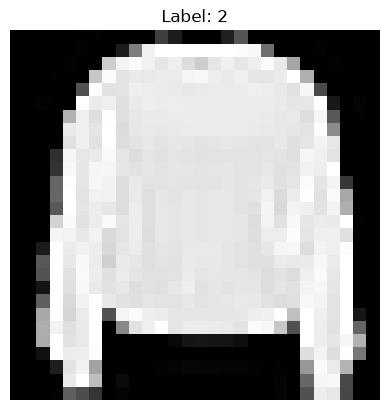

In [4]:
index = 7 #CHANGE ACCORDINGLY TO SEE DIFFERENT IMAGES

plt.imshow(X_train[index].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[index]}")
plt.axis("off")
plt.show()

In [5]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T

Y_train = data_train[0].astype(int)

X_train = data_train[1:n]

data_dev = data[0:1000].T

Y_dev = data_dev[0].astype(int)

X_dev = data_dev[1:n]

_,m_train = X_train.shape

In [6]:
Y_train


array([9, 3, 3, ..., 4, 6, 1], shape=(59000,))

ALL THE FUNCTION WE NEED TO ESTABLISH THE NERUAL NETWORK

In [7]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    Y = Y.astype(int)

    one_hot_Y = np.zeros((Y.size, int(Y.max()) + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T

    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [8]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [9]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[2 1 1 ... 2 2 2] [9 3 3 ... 4 6 1]
0.16722033898305086
Iteration:  10
[9 1 1 ... 2 2 1] [9 3 3 ... 4 6 1]
0.33547457627118643
Iteration:  20
[9 3 3 ... 2 2 1] [9 3 3 ... 4 6 1]
0.4527118644067797
Iteration:  30
[9 3 3 ... 2 2 1] [9 3 3 ... 4 6 1]
0.5181525423728813
Iteration:  40
[9 3 3 ... 2 2 1] [9 3 3 ... 4 6 1]
0.5627118644067797
Iteration:  50
[9 3 3 ... 2 2 1] [9 3 3 ... 4 6 1]
0.5940169491525423
Iteration:  60
[9 3 3 ... 2 2 1] [9 3 3 ... 4 6 1]
0.6121864406779661
Iteration:  70
[9 3 3 ... 2 2 1] [9 3 3 ... 4 6 1]
0.6253898305084746
Iteration:  80
[9 3 3 ... 2 2 1] [9 3 3 ... 4 6 1]
0.6352711864406779
Iteration:  90
[9 3 3 ... 2 4 1] [9 3 3 ... 4 6 1]
0.6397457627118645
Iteration:  100
[9 3 3 ... 4 4 1] [9 3 3 ... 4 6 1]
0.6227457627118644
Iteration:  110
[9 3 3 ... 2 4 1] [9 3 3 ... 4 6 1]
0.6301016949152543
Iteration:  120
[9 3 3 ... 2 4 1] [9 3 3 ... 4 6 1]
0.6364745762711864
Iteration:  130
[9 3 3 ... 2 4 1] [9 3 3 ... 4 6 1]
0.6433728813559322
Iteration:  140

In [10]:
print(X_train.shape)
print(Y_train.shape)

print(X_train.dtype)
print(Y_train.dtype)

print(np.min(X_train), np.max(X_train))

print(np.unique(Y_train))

(784, 59000)
(59000,)
float32
int64
0.0 1.0
[0 1 2 3 4 5 6 7 8 9]


In [11]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", class_names[prediction[0]])
    print("Label: ", class_names[label])
  
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  Dress
Label:  Dress


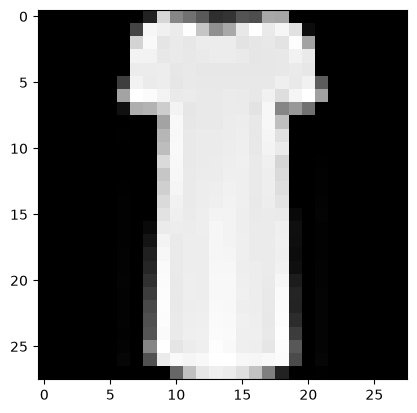

Prediction:  Bag
Label:  Bag


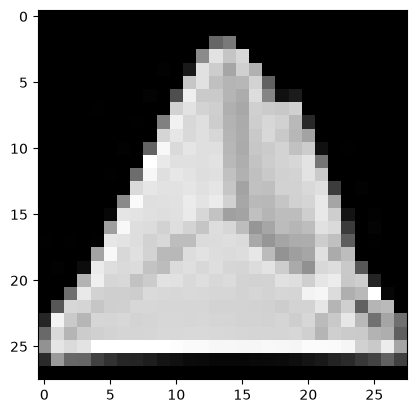

Prediction:  Dress
Label:  Dress


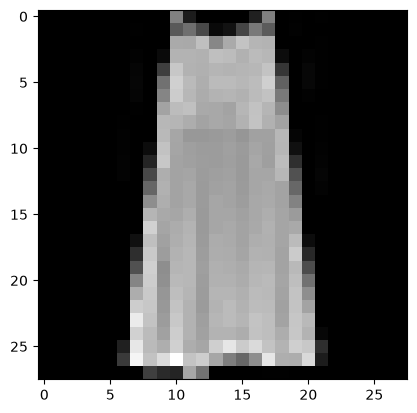

Prediction:  Coat
Label:  Pullover


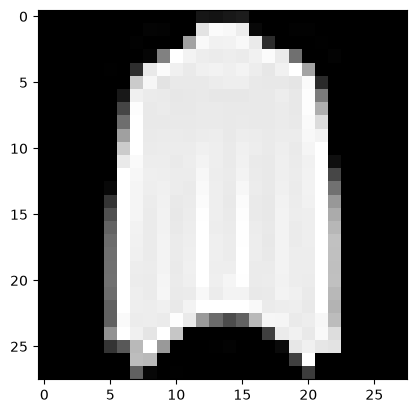

In [12]:
test_prediction(6, W1, b1, W2, b2)
test_prediction(9, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [13]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[5 7 7 4 5 6 8 3 4 4 5 0 4 3 6 5 8 6 8 4 8 4 5 7 3 5 4 5 0 6 1 9 4 4 9 3 8
 2 6 2 7 9 5 9 9 7 5 4 2 6 4 6 9 1 7 1 0 7 4 9 2 9 1 1 6 3 1 7 8 2 0 0 4 7
 8 6 4 2 4 3 7 9 4 0 8 9 1 3 8 1 4 4 7 9 9 5 0 4 3 0 1 7 7 8 3 7 4 0 9 4 9
 8 7 1 7 5 4 0 0 5 2 7 6 7 9 0 3 4 1 2 0 9 5 5 0 9 0 4 8 4 3 9 4 4 1 3 2 1
 4 1 8 6 1 7 3 8 1 1 0 1 5 3 8 9 9 0 7 6 4 4 8 3 7 4 7 3 7 9 0 1 9 7 7 4 4
 3 4 9 8 7 1 0 7 5 9 2 9 7 8 5 1 4 1 8 5 3 2 9 3 1 4 7 1 9 3 7 8 4 7 4 2 9
 7 8 2 5 8 0 0 3 4 9 9 4 1 9 2 0 4 0 5 5 4 3 1 5 8 9 4 5 3 8 7 5 8 2 8 8 7
 7 7 3 9 4 8 0 8 1 1 5 0 6 3 1 8 1 9 4 6 2 4 0 4 0 4 3 2 8 4 9 9 3 8 0 4 2
 9 9 2 4 5 1 3 0 5 5 3 6 9 3 3 6 9 1 9 7 4 0 6 3 3 1 1 8 1 1 9 3 0 0 3 0 4
 3 0 8 1 2 7 4 0 0 0 4 4 8 2 3 9 3 5 8 3 1 6 1 3 0 8 5 3 4 3 3 0 6 9 4 5 9
 8 4 8 4 3 1 9 9 7 3 8 0 0 0 6 2 0 3 5 4 9 0 9 5 7 7 6 4 6 3 5 7 1 4 5 2 8
 9 4 4 1 7 9 6 8 7 3 1 7 3 0 7 1 8 0 6 6 1 1 5 4 7 0 1 8 3 9 0 0 4 5 9 0 7
 4 9 7 8 5 8 7 2 4 4 8 9 1 3 5 1 6 4 4 4 0 0 0 4 1 2 0 7 7 0 6 1 1 5 4 5 1
 1 1 7 4 0 5 0 5 5 4 1 4 

np.float64(0.757)